# Sensitivity Analysis: Landmark Window Position

Tests whether cross-condition landmark preference results are robust to shifts in the landmark window positions (±5 cm and ±10 cm).

Landmark positions per animal were defined by visual inspection of spatial response maps from the active VR session (LastDay) and applied uniformly across all three conditions. This notebook checks that the main findings do not depend on the exact choice of window center.

**Shifts tested**: −10, −5, 0, +5, +10 cm  
**Window shape**: unchanged (same `before`/`after` per animal)  
**Output**: proportion vs shift plots per layer — cross-condition ordering should be preserved across shifts

In [15]:
import sys
sys.path.insert(0, r'C:\Users\jasmineyeo\Documents\GitHub\V1_SpatialModulation')
sys.path.insert(0, r'C:\Users\jasmineyeo\Documents\GitHub\V1_SpatialModulation\3.LandmarkPreference')

import io
import os
import glob
import contextlib
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams

from LandmarkPreference_OpenLoopVR_Analysis import (
    identify_landmark_responses,
    analyze_layer_landmark_preferences,
)
from helper import files as hfiles
from helper import TwoP
from helper.SpatialModulationIndexLayerSpecific import SpatialModulationIndexLayerSpecific as SMI_Layer

%matplotlib inline

rcParams['legend.fontsize'] = 13
rcParams['axes.labelsize']  = 13
rcParams['axes.titlesize']  = 14
rcParams['xtick.labelsize'] = 11
rcParams['ytick.labelsize'] = 11

CONDITIONS  = ['LastDay', 'OpenLoop_Moving', 'OpenLoop_Stationary']
COND_LABELS = ['Last Day', 'Day 8 (Moving)', 'Day 9 (Stationary)']
COND_COLORS = ['#2196F3', '#FF9800', '#E53935']
LAYER_NAMES = ['L2/3', 'L4', 'L5', 'L6']

print('Setup complete.')

Setup complete.


In [16]:
# ── Sessions (copy from LandmarkPreference_OpenLoopVR.ipynb) ─────────────────
SESSIONS = [
    {
        'animal_id':           'JSY044',
        'LastDay':             r'D:\V1_SpatialModulation\2p\V1_prism\JSY044_ChronicImaging\250912_JSY_JSY044_SpatialModulation_Day7\TSeries-09122025-1334-001',
        'OpenLoop_Moving':     r'D:\V1_SpatialModulation\2p\V1_prism\JSY044_ChronicImaging\251122_JSY_JSY044_SpMod_OpenLoopVR_Moving\TSeries-11222025-1339-001',
        'OpenLoop_Stationary': r'D:\V1_SpatialModulation\2p\V1_prism\JSY044_ChronicImaging\251123_JSY_JSY044_SpMod_OpenLoopVR_Stationary\TSeries-11232025-1222-001',
    },
    {
        'animal_id':           'JSY051',
        'LastDay':             r'D:\V1_SpatialModulation\2p\V1_prism\JSY051_ChronicImaging\251105_JSY_JSY051_SpMod_Day5\TSeries-11052025-1512-002',
        'OpenLoop_Moving':     r'D:\V1_SpatialModulation\2p\V1_prism\JSY051_ChronicImaging\251106_JSY_JSY051_SpMO_OpenloopVR_moving\TSeries-11062025-1439-002',
        'OpenLoop_Stationary': r'D:\V1_SpatialModulation\2p\V1_prism\JSY051_ChronicImaging\251107_JSY_JSY051_SpMO_OpenloopVR_stationary\TSeries-11072025-1032-001',
    },
    {
        'animal_id':           'JSY052',
        'LastDay':             r'D:\V1_SpatialModulation\2p\V1_prism\JSY052_ChronicImaging\251015_JSY_JSY052_SpatialModulation_Day7\TSeries-10152025-1103-001',
        'OpenLoop_Moving':     r'D:\V1_SpatialModulation\2p\V1_prism\JSY052_ChronicImaging\251122_JSY_JSY052_SpMod_OpenLoopVR_Moving\TSeries-11222025-1339-001',
        'OpenLoop_Stationary': r'D:\V1_SpatialModulation\2p\V1_prism\JSY052_ChronicImaging\251123_JSY_JSY052_SpMod_OpenLoopVR_Stationary\TSeries-11232025-1222-002',
    },
    {
        'animal_id':           'JSY054',
        'LastDay':             r'D:\V1_SpatialModulation\2p\V1_prism\JSY054_ChronicImaging\251105_JSY_JSY054_SpMod_Day7\TSeries-11052025-1512-001',
        'OpenLoop_Moving':     r'D:\V1_SpatialModulation\2p\V1_prism\JSY054_ChronicImaging\251106_JSY_JSY054_SpMO_OpenloopVR_moving\TSeries-11062025-1439-001',
        'OpenLoop_Stationary': r'D:\V1_SpatialModulation\2p\V1_prism\JSY054_ChronicImaging\251107_JSY_JSY054_SpMO_OpenloopVR_stationary\TSeries-11072025-1032-001',
    },
    {
        'animal_id':           'JSY055',
        'LastDay':             r'D:\V1_SpatialModulation\2p\V1_prism\JSY055_ChronicImaging\251211_JSY_JSY055_SpatialModulation_Day7\TSeries-12112025-1631-001',
        'OpenLoop_Moving':     r'D:\V1_SpatialModulation\2p\V1_prism\JSY055_ChronicImaging\251212_JSY_JSY055_SpatialModulation_OpenLoopVR_Moving\TSeries-12122025-1421-001',
        'OpenLoop_Stationary': r'D:\V1_SpatialModulation\2p\V1_prism\JSY055_ChronicImaging\251213_JSY_JSY055_SpatialModulation_OpenLoopVR_Stationary\TSeries-12132025-1711-001',
    },
]

# ── Per-animal base landmark parameters ──────────────────────────────────────
# positions: the nominal landmark centers used in the main analysis
# windows:   the before/after config — kept fixed during the shift sweep
ANIMAL_BASE_PARAMS = {
    'JSY044': {'positions': [25, 55, 85, 115], 'windows': [{'before': 15, 'after': 10}] * 4},
    'JSY051': {'positions': [25, 55, 85, 115], 'windows': [{'before': 15, 'after': 10}] * 4},
    'JSY052': {'positions': [25, 55, 85, 115], 'windows': [{'before': 15, 'after': 10}] * 4},
    'JSY054': {'positions': [25, 55, 85, 115], 'windows': [{'before': 15, 'after': 10}] * 4},
    'JSY055': {'positions': [37, 65, 93, 120], 'windows': [{'before': 25, 'after':  3}] * 4},
}

# ── Animals to include in this run ───────────────────────────────────────────
INCLUDE_ANIMALS = [
    'JSY044',
    'JSY051',
    'JSY052',
    'JSY054',
    'JSY055',
]

# ── Shift values to test ──────────────────────────────────────────────────────
SHIFTS = [-10, -5, 0, +5, +10]   # cm

# ── Fixed analysis parameters (same as main notebook) ────────────────────────
BOUNDARY_EXCLUSION  = (5, 5)
EXCLUDE_FIRST_BINS  = 5
EXCLUDE_LAST_BINS   = 5
SMOOTHING_SIGMA     = 1.0

included_sessions = [s for s in SESSIONS if s['animal_id'] in INCLUDE_ANIMALS]
print(f'Animals: {[s["animal_id"] for s in included_sessions]}')
print(f'Shifts:  {SHIFTS} cm')

Animals: ['JSY044', 'JSY051', 'JSY052', 'JSY054', 'JSY055']
Shifts:  [-10, -5, 0, 5, 10] cm


In [17]:
def load_session_data(session_dir):
    """Load preproc data and compute reliable-cell layer assignments for one session."""
    preproc_files = glob.glob(os.path.join(session_dir, '*preproc*.h5'))
    if not preproc_files:
        raise ValueError(f'No preproc .h5 found in {session_dir}')

    preproc_data = hfiles.read_h5(preproc_files[0])
    norm_spatial = preproc_data['norm_spatial_activity']
    bin_centers  = preproc_data['bin_centers']
    reliable     = preproc_data['combined_reliable']

    twoP_fn   = os.path.basename(session_dir)
    raw_twop  = TwoP(session_dir, twoP_fn)
    raw_twop.find_files()
    twop_dict = raw_twop.calc_dFF()
    med_coords = np.array([cell['med'] for cell in twop_dict['stat']])
    layer_cells, _ = SMI_Layer.identify_layers(med_coords)

    reliable_idx          = np.where(reliable)[0]
    norm_spatial_reliable = norm_spatial[reliable_idx]
    layer_cells_reliable  = {
        layer: np.where(np.isin(reliable_idx, idx))[0]
        for layer, idx in layer_cells.items()
    }
    return norm_spatial_reliable, bin_centers, layer_cells_reliable, len(reliable_idx)


print('load_session_data defined.')

load_session_data defined.


In [18]:
# ── Run the sensitivity sweep ─────────────────────────────────────────────────
# Results structure:
#   sweep[animal][condition][shift][layer] = {'proportions': array, 'n_cells': int}

sweep = {}

for s in included_sessions:
    animal   = s['animal_id']
    base_pos = ANIMAL_BASE_PARAMS[animal]['positions']
    base_win = ANIMAL_BASE_PARAMS[animal]['windows']
    sweep[animal] = {}

    for cond in CONDITIONS:
        print(f'Loading {animal} / {cond}...')
        norm_spatial, bin_centers, layer_cells, n_rel = load_session_data(s[cond])
        print(f'  {n_rel} reliable cells loaded.')
        reliable_valid = np.ones(n_rel, dtype=bool)
        sweep[animal][cond] = {}

        for shift in SHIFTS:
            shifted_pos = [p + shift for p in base_pos]

            # Suppress verbose output from identify_landmark_responses
            with contextlib.redirect_stdout(io.StringIO()):
                lm_results = identify_landmark_responses(
                    norm_spatial, bin_centers, shifted_pos,
                    landmark_windows_config=base_win,
                    boundary_exclusion=BOUNDARY_EXCLUSION,
                    smoothing_sigma=SMOOTHING_SIGMA,
                    exclude_first_bins=EXCLUDE_FIRST_BINS,
                    exclude_last_bins=EXCLUDE_LAST_BINS,
                )
                layer_results = analyze_layer_landmark_preferences(
                    lm_results, layer_cells, reliable_valid
                )

            shift_data = {}
            for layer in LAYER_NAMES:
                lr = layer_results.get(layer)
                if lr is not None and len(lr.get('valid_cells', [])) > 0:
                    shift_data[layer] = {
                        'proportions': lr['landmark_proportions'].copy(),
                        'n_cells':     int(lr['stats']['n_cells']),
                    }
                else:
                    shift_data[layer] = None

            sweep[animal][cond][shift] = shift_data
            n_valid = int(np.sum(lm_results['valid_cells']))
            print(f'  shift={shift:+d} cm  →  {n_valid} landmark-preferring cells')

print('\nSweep complete.')

Loading JSY044 / LastDay...
Automatically detected peak density at y = 369.04
Layer 2/3: 291 cells in from 77.00 to 296.04
Layer 4: 371 cells in from 296.04 to 442.04
Layer 5: 127 cells in from 442.04 to 600.04
Layer 6: 58 cells in from 600.04 to 673.00
  401 reliable cells loaded.
  shift=-10 cm  →  273 landmark-preferring cells
  shift=-5 cm  →  287 landmark-preferring cells
  shift=+0 cm  →  189 landmark-preferring cells
  shift=+5 cm  →  217 landmark-preferring cells
  shift=+10 cm  →  220 landmark-preferring cells
Loading JSY044 / OpenLoop_Moving...
Automatically detected peak density at y = 362.95
Layer 2/3: 263 cells in from 70.00 to 289.95
Layer 4: 424 cells in from 289.95 to 435.95
Layer 5: 149 cells in from 435.95 to 593.95
Layer 6: 60 cells in from 593.95 to 721.00
  280 reliable cells loaded.
  shift=-10 cm  →  260 landmark-preferring cells
  shift=-5 cm  →  259 landmark-preferring cells
  shift=+0 cm  →  47 landmark-preferring cells
  shift=+5 cm  →  68 landmark-preferring

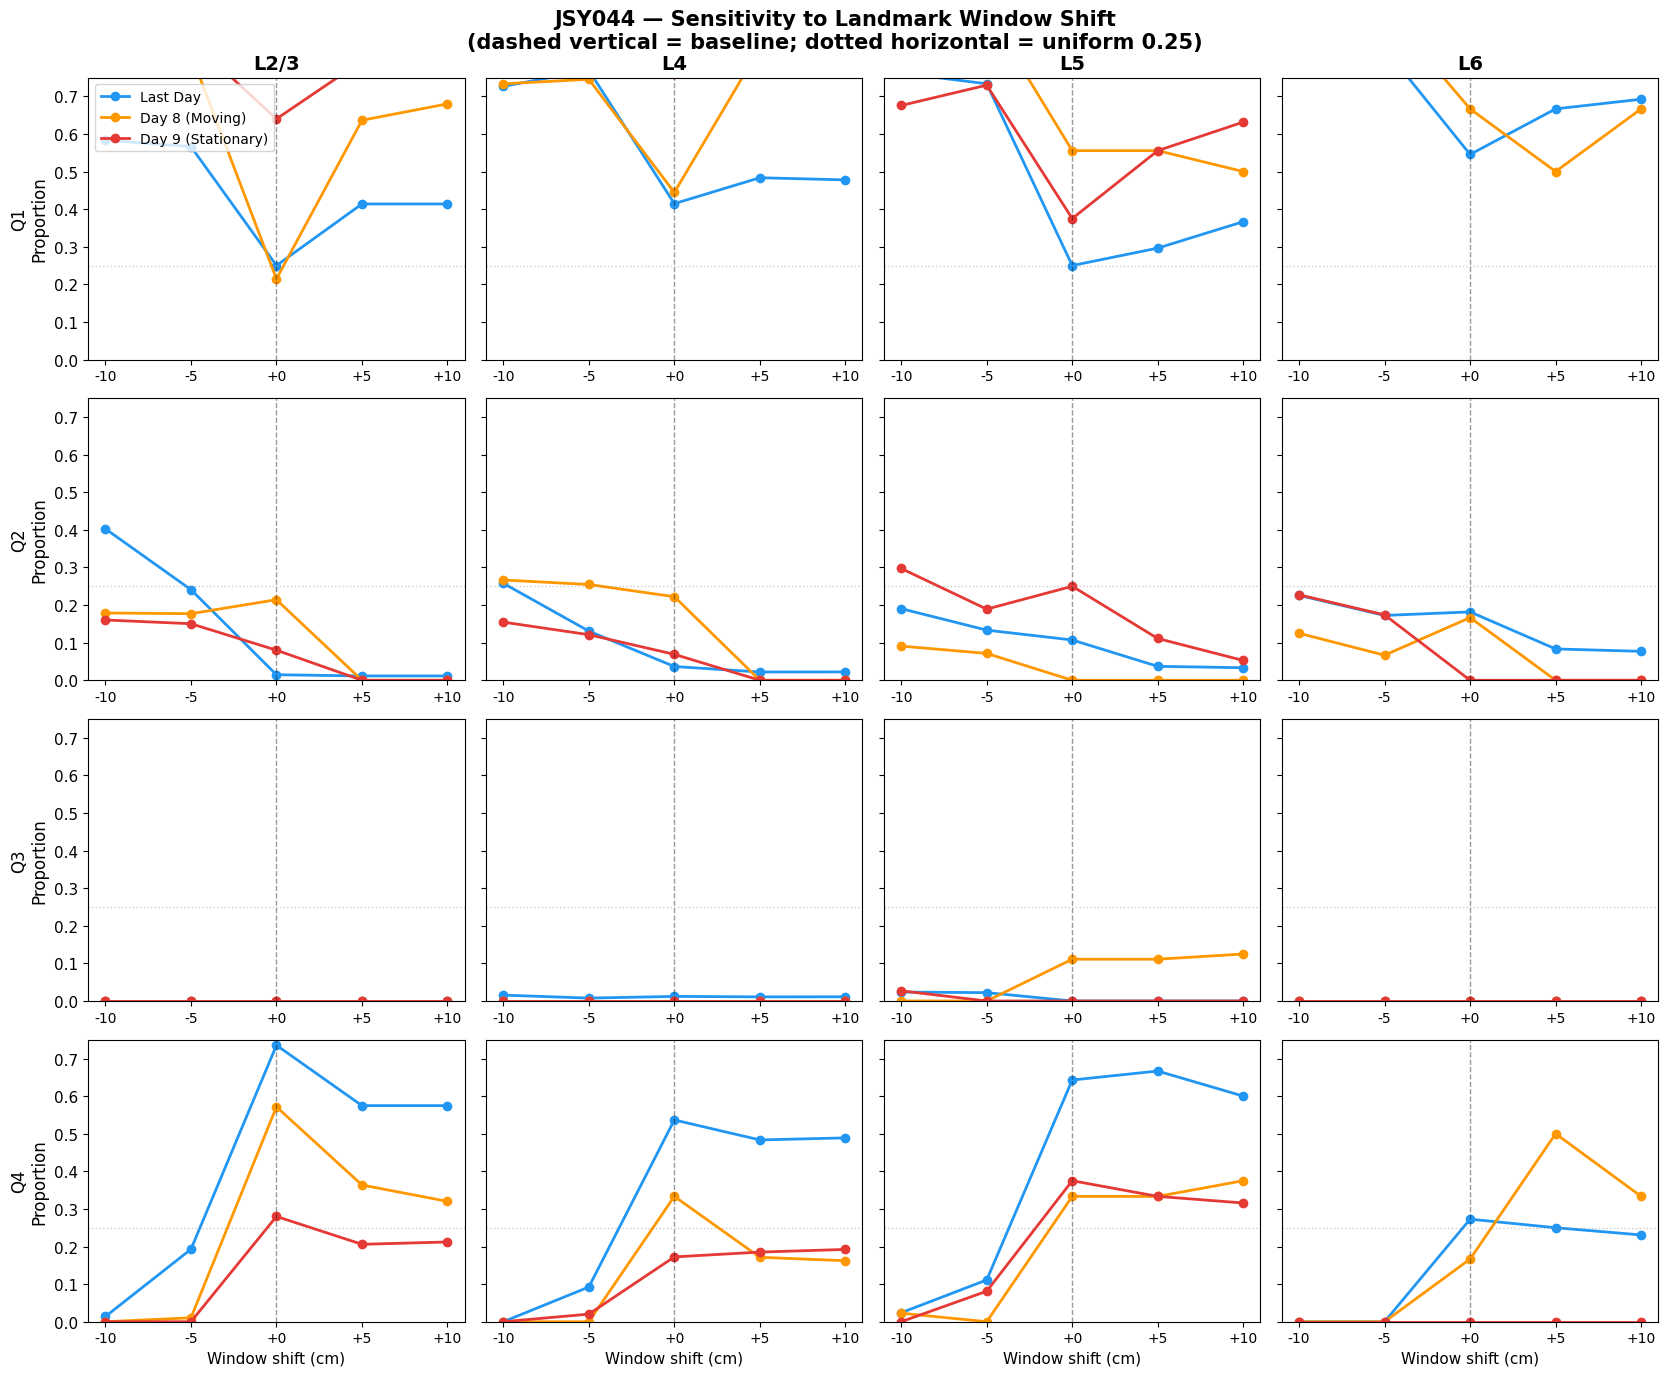

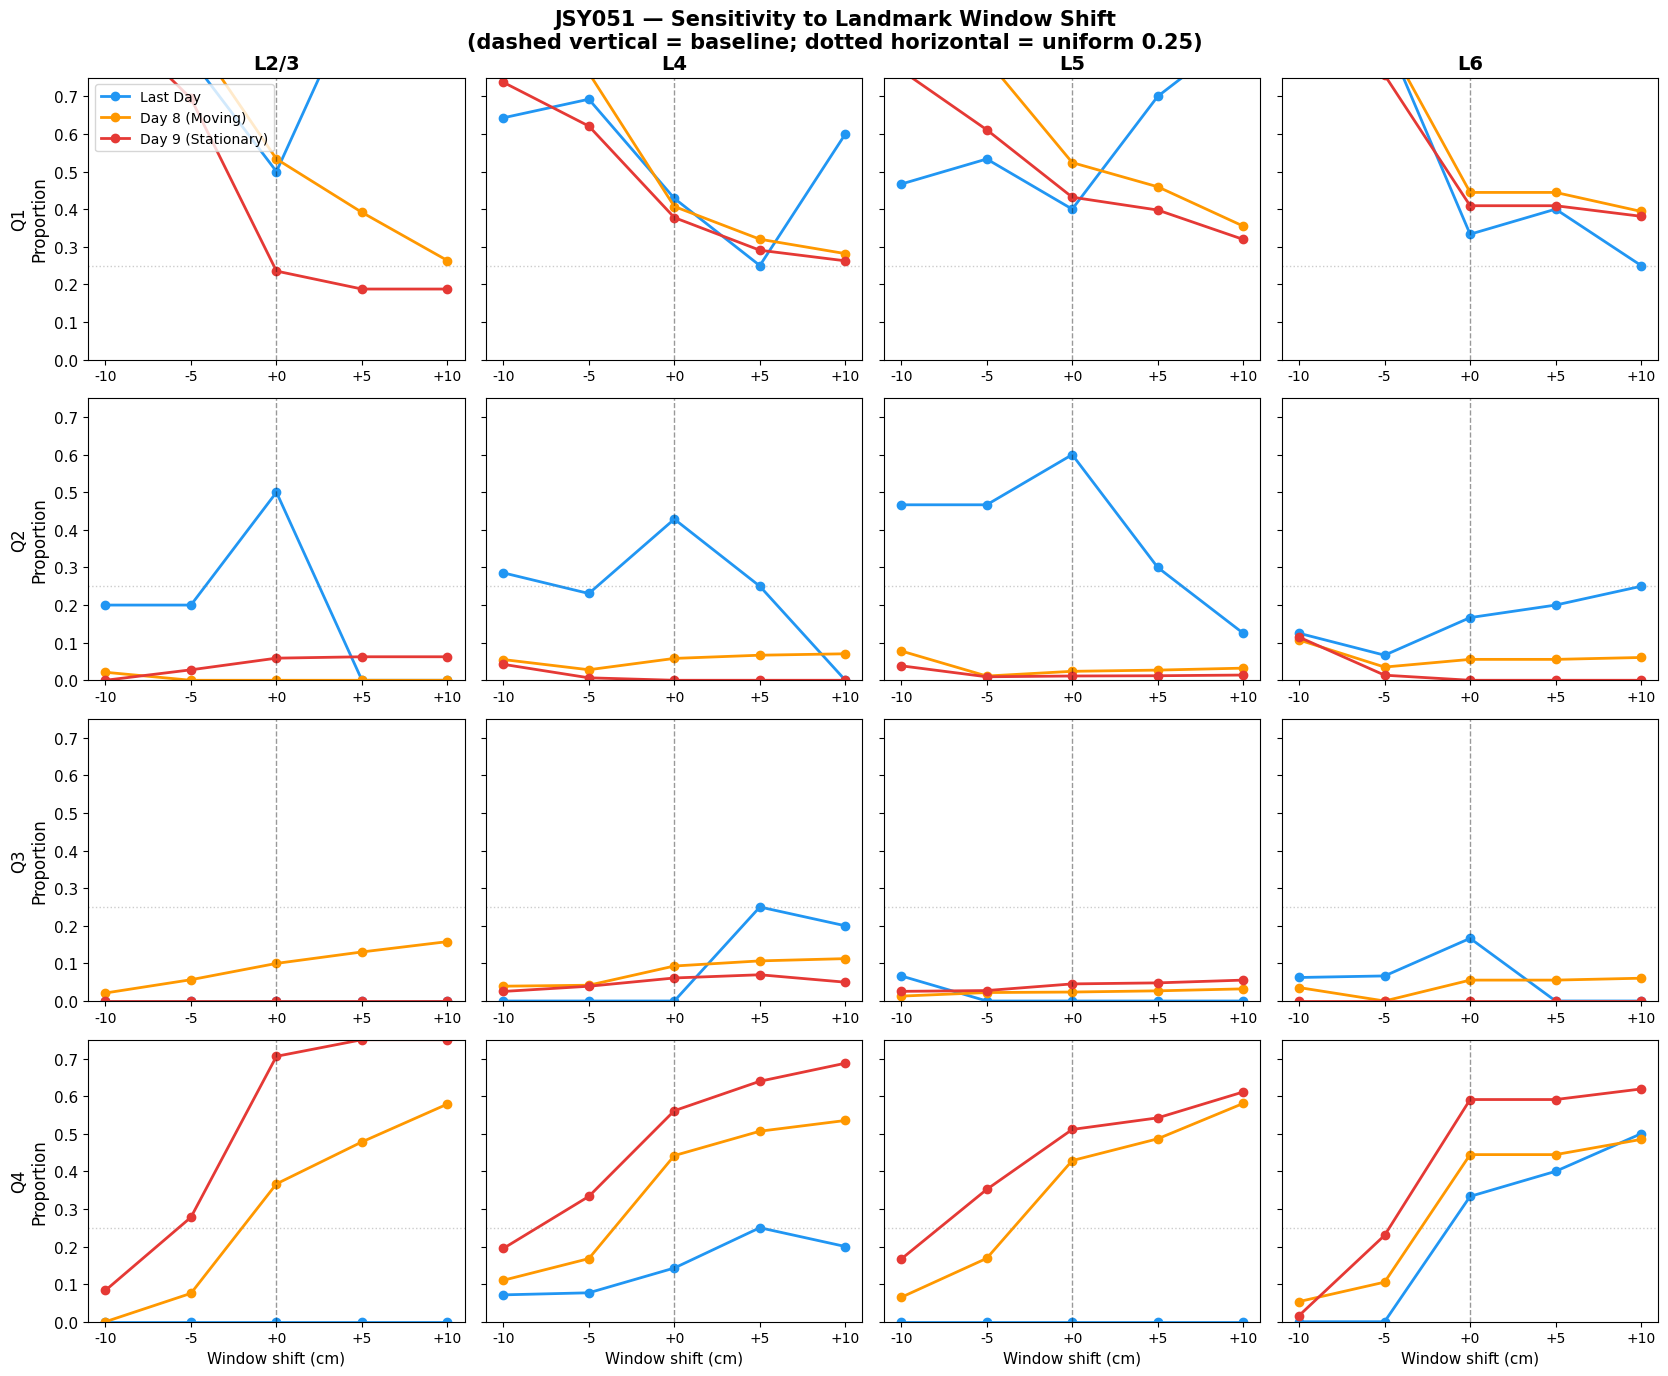

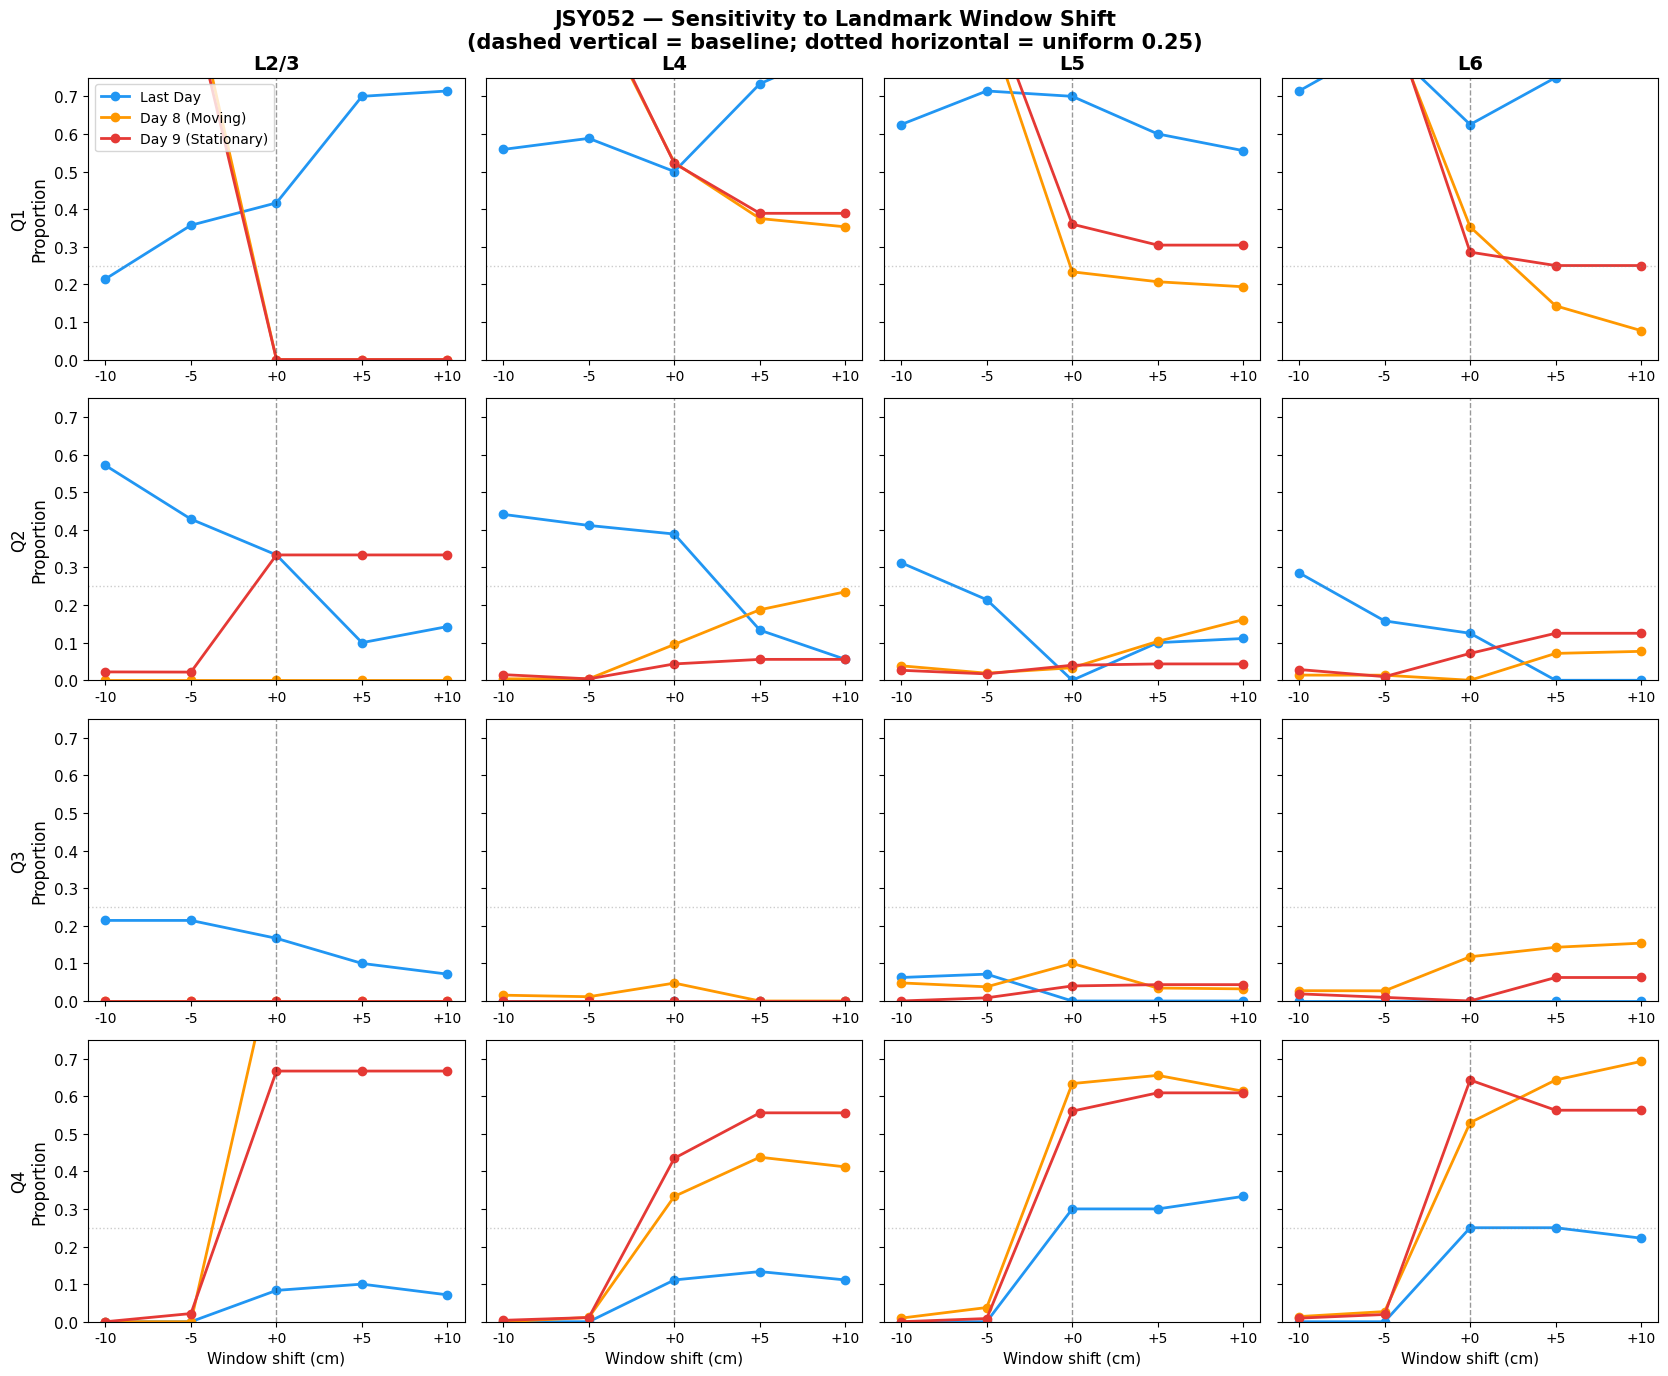

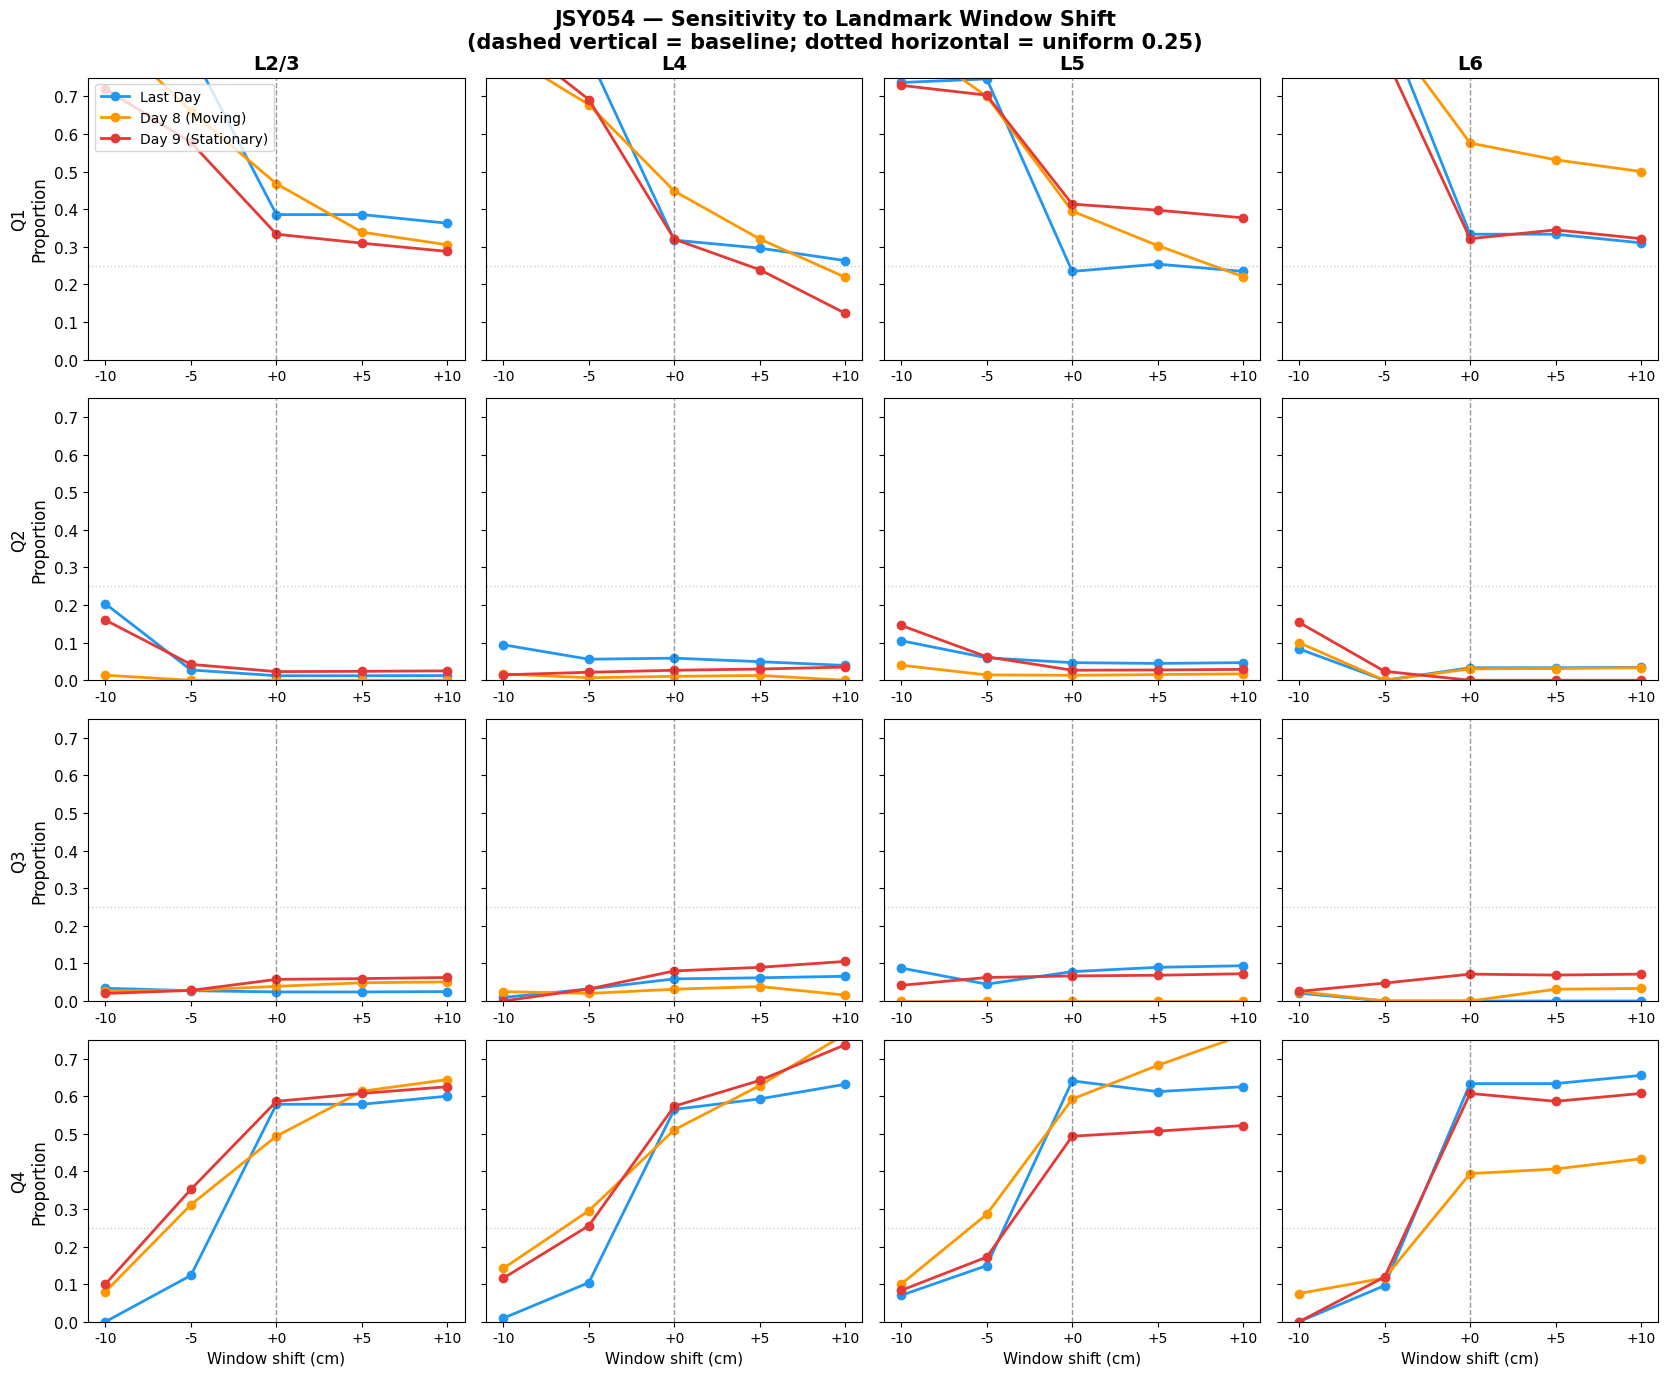

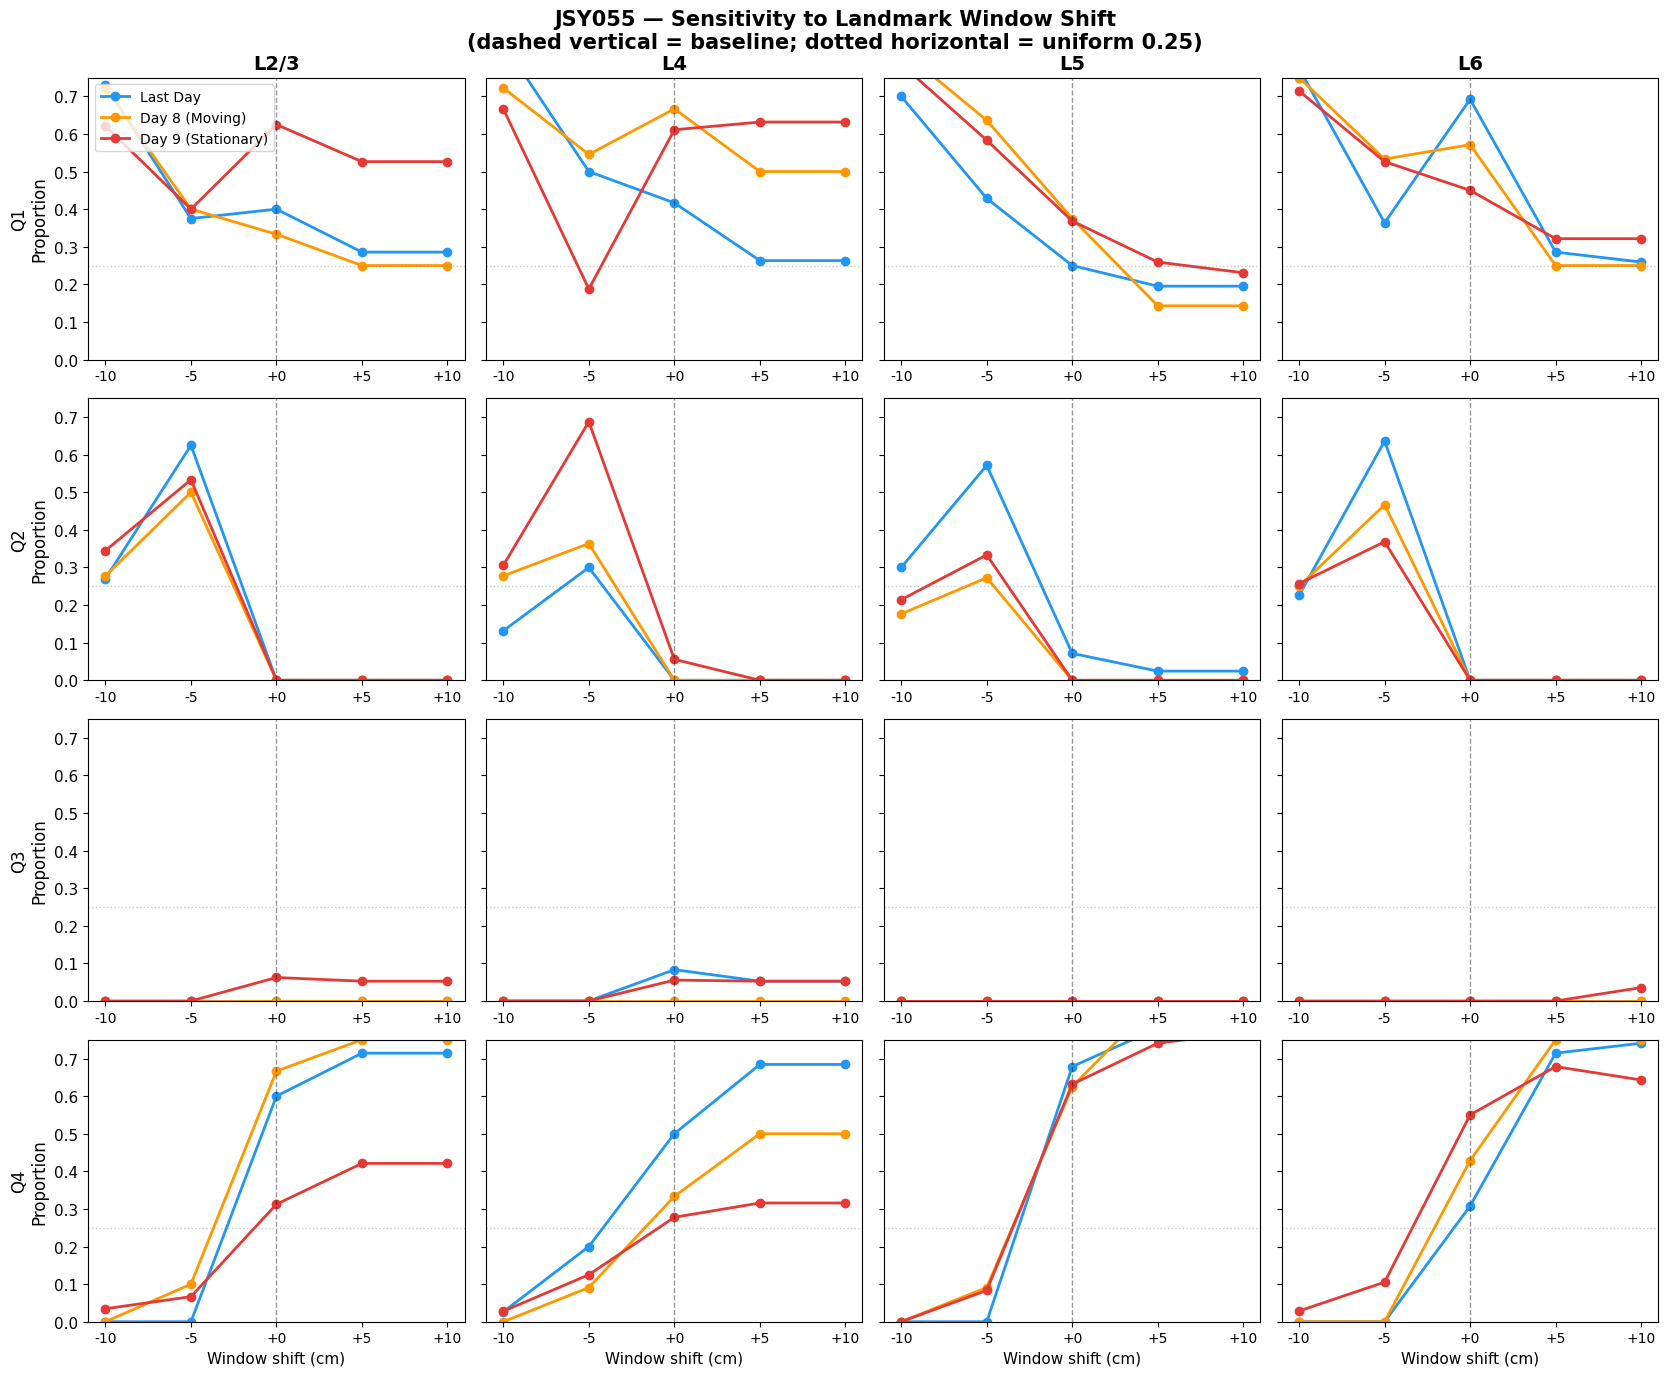

In [19]:
# ── Figure 1: Proportion vs shift, per landmark, per layer ───────────────────
# One figure per animal.
# Layout: rows = landmarks (Q1–Q4), cols = layers (L2/3–L6).
# Each panel: x = shift, lines = conditions.
# If cross-condition ordering is preserved across the x-axis, the result is robust.

LM_LABELS = [f'Q{i+1}' for i in range(4)]

for s in included_sessions:
    animal = s['animal_id']
    fig, axes = plt.subplots(
        len(LM_LABELS), len(LAYER_NAMES),
        figsize=(4.2 * len(LAYER_NAMES), 3.5 * len(LM_LABELS)),
        sharey='row',
    )

    for lm_idx, lm_label in enumerate(LM_LABELS):
        for li, layer in enumerate(LAYER_NAMES):
            ax = axes[lm_idx, li]

            for ci, (cond, cond_label, cond_color) in enumerate(
                    zip(CONDITIONS, COND_LABELS, COND_COLORS)):
                vals = []
                for shift in SHIFTS:
                    d = sweep[animal][cond][shift].get(layer)
                    if d is not None:
                        vals.append(float(d['proportions'][lm_idx]))
                    else:
                        vals.append(np.nan)

                ax.plot(SHIFTS, vals, 'o-', color=cond_color, lw=2,
                        ms=6, label=cond_label)

            ax.axvline(0, color='k', lw=1, ls='--', alpha=0.4)
            ax.axhline(0.25, color='gray', lw=1, ls=':', alpha=0.4)
            ax.set_xticks(SHIFTS)
            ax.set_xticklabels([f'{s:+d}' for s in SHIFTS], fontsize=10)
            ax.set_ylim(0, 0.75)

            if lm_idx == 0:
                ax.set_title(layer, fontsize=14, fontweight='bold')
            if li == 0:
                ax.set_ylabel(f'{lm_label}\nProportion', fontsize=12)
            if lm_idx == len(LM_LABELS) - 1:
                ax.set_xlabel('Window shift (cm)', fontsize=11)

    # Legend on first panel
    axes[0, 0].legend(fontsize=10, loc='upper left')

    fig.suptitle(
        f'{animal} — Sensitivity to Landmark Window Shift\n'
        f'(dashed vertical = baseline; dotted horizontal = uniform 0.25)',
        fontsize=15, fontweight='bold'
    )
    plt.tight_layout()
    plt.show()

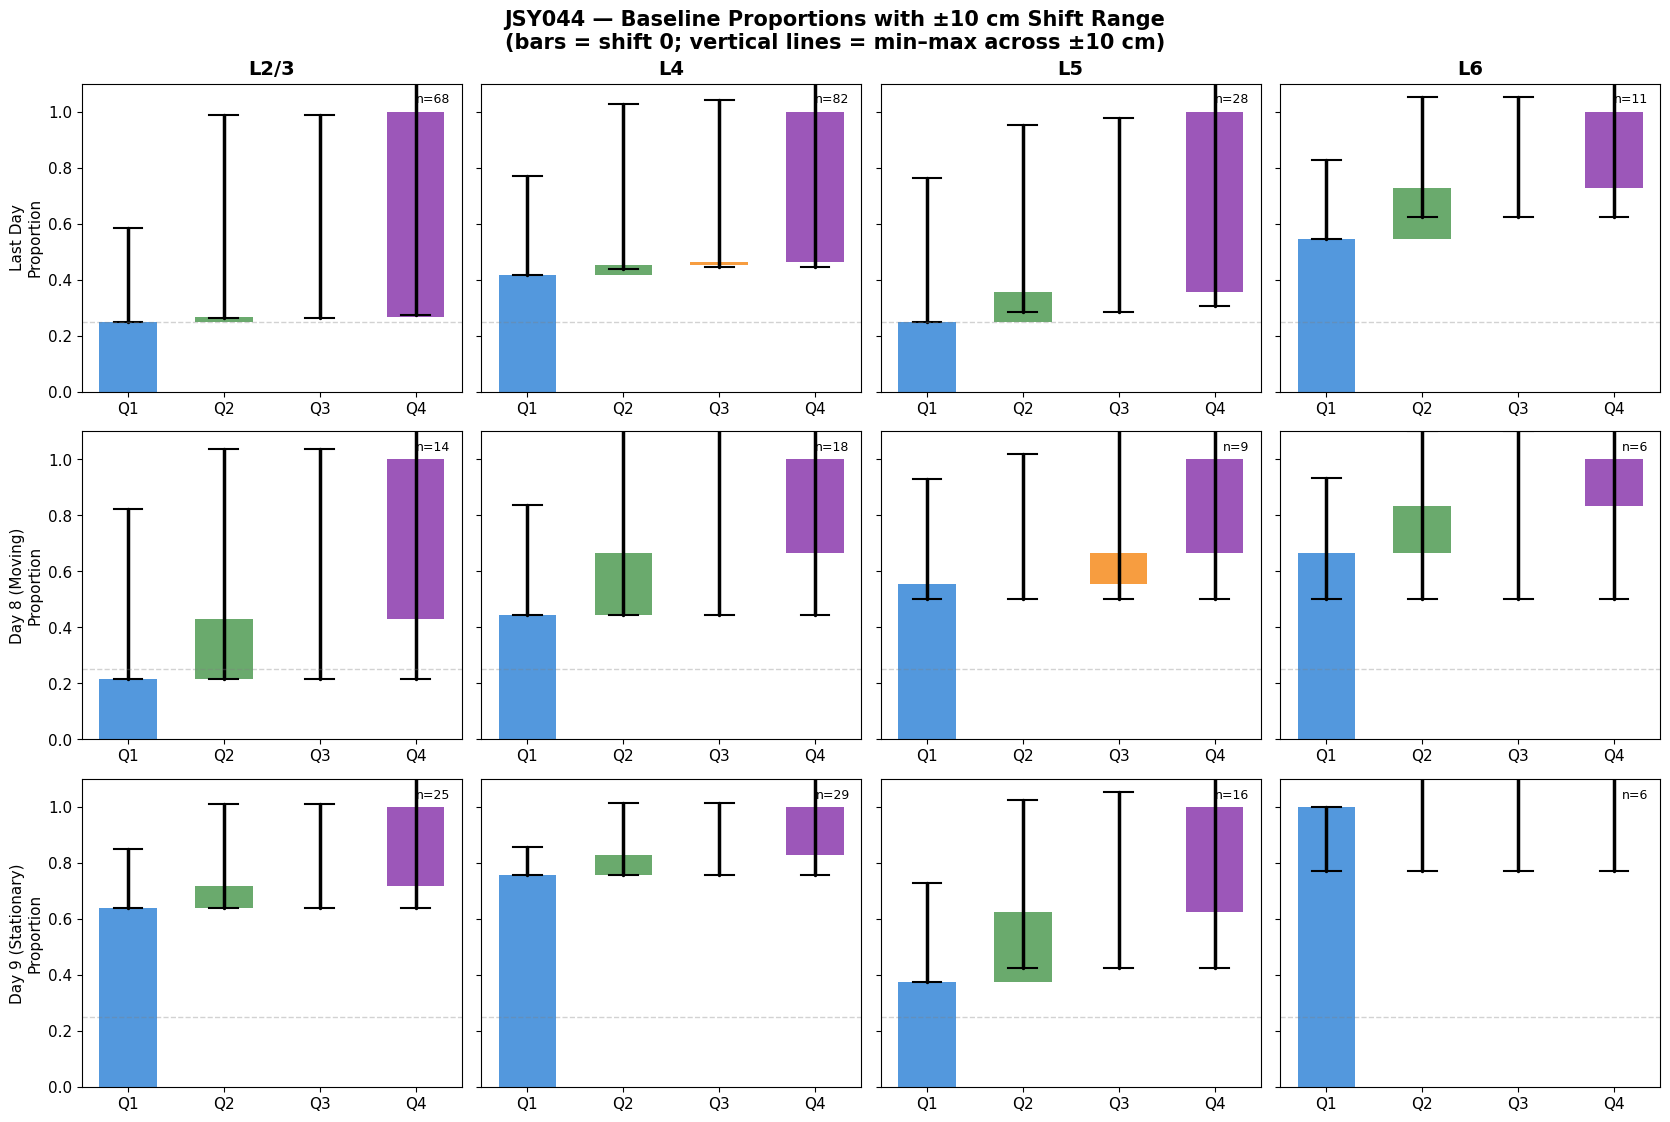

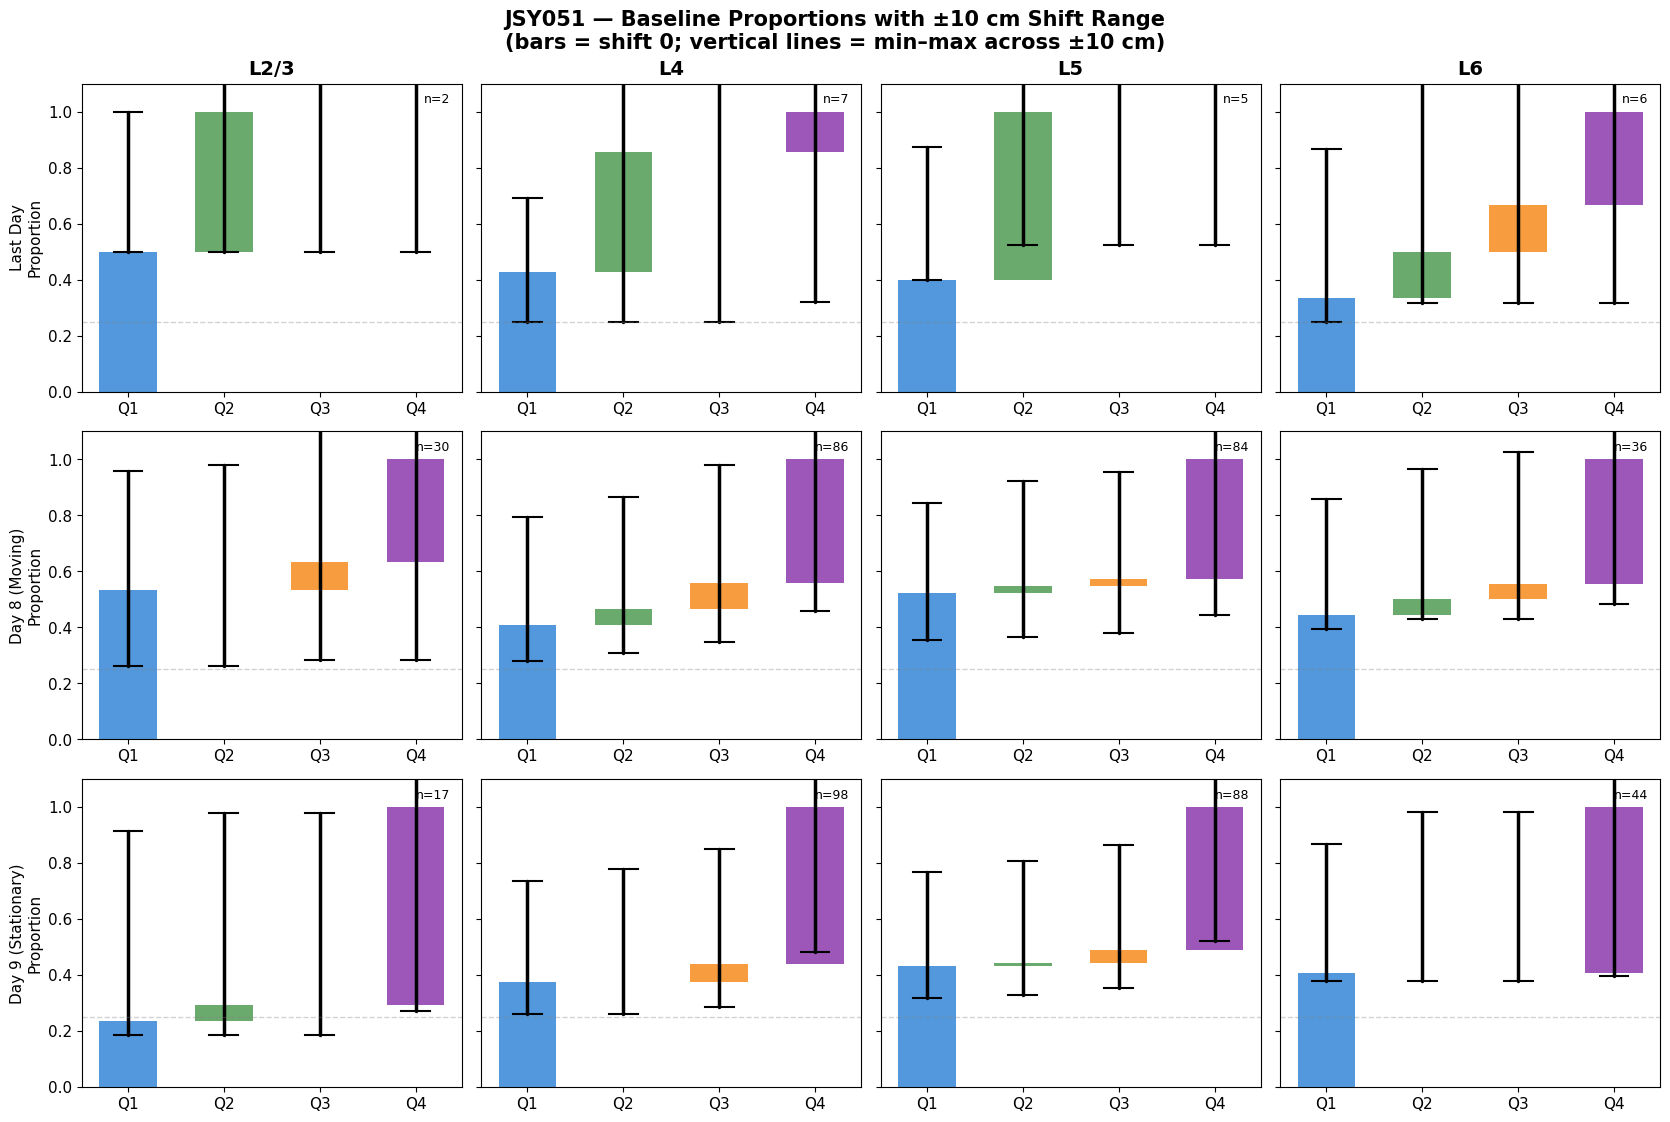

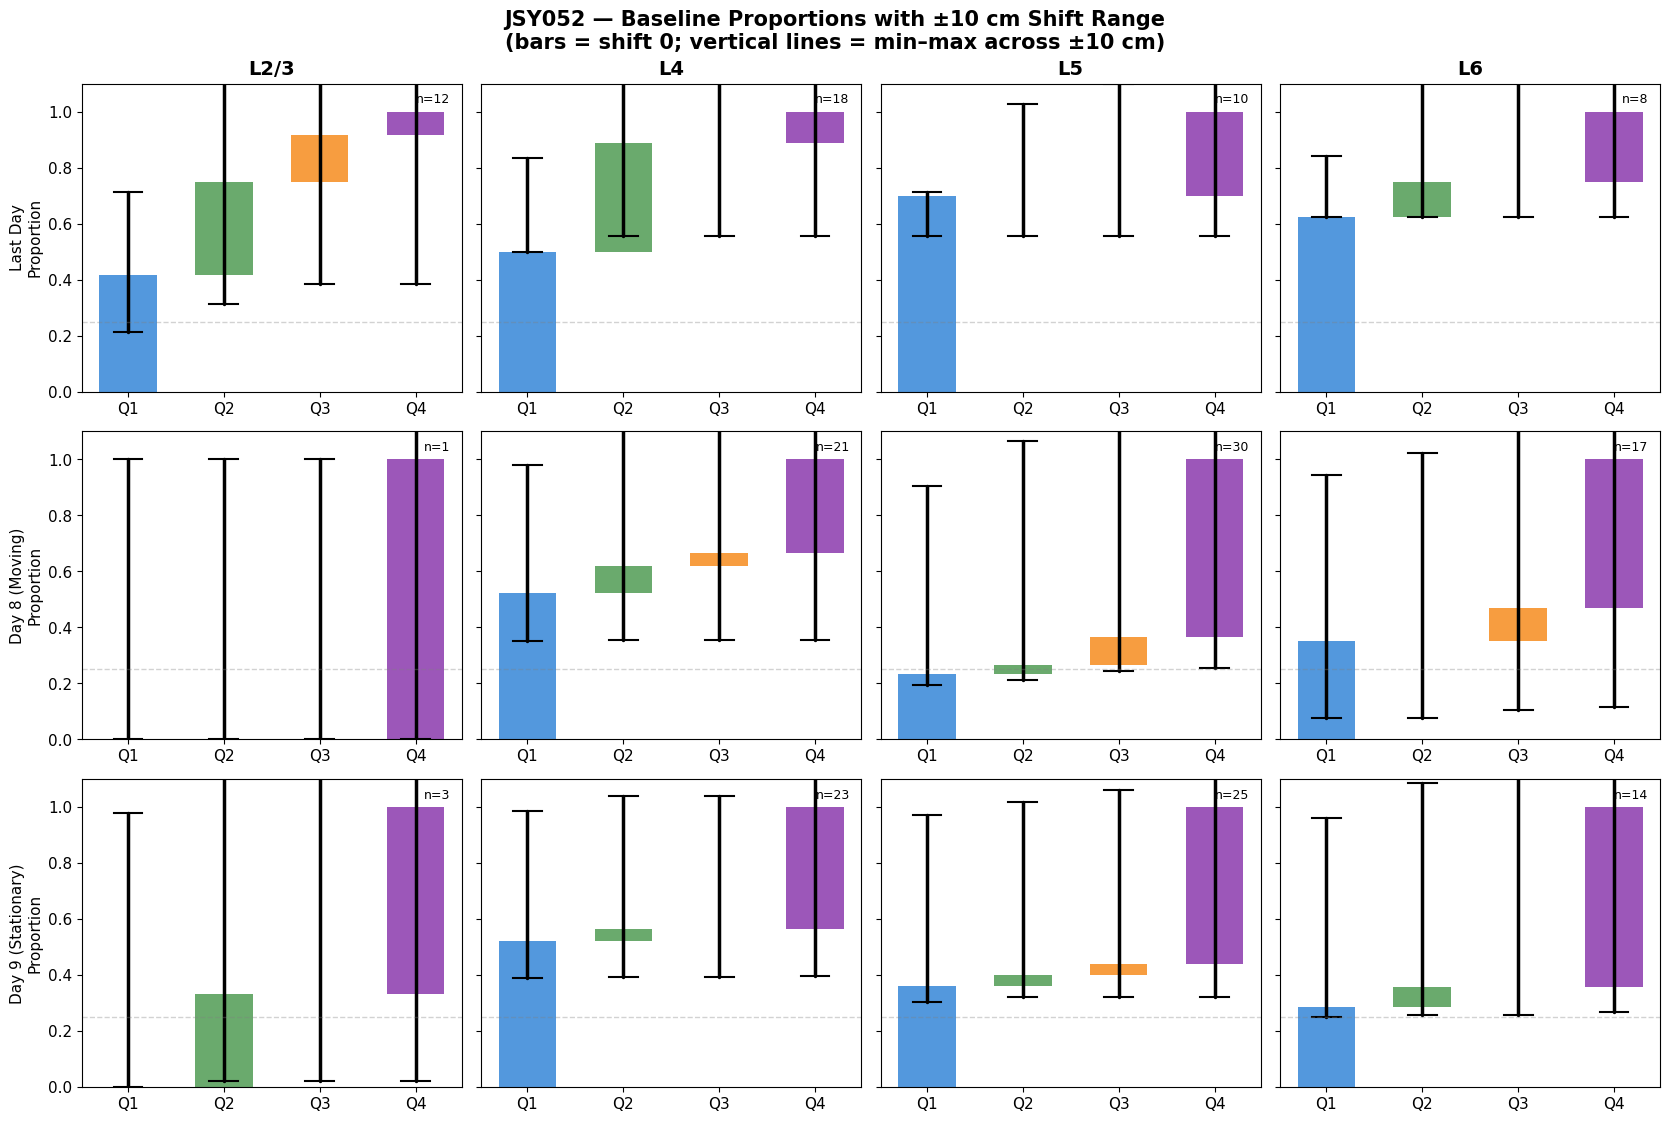

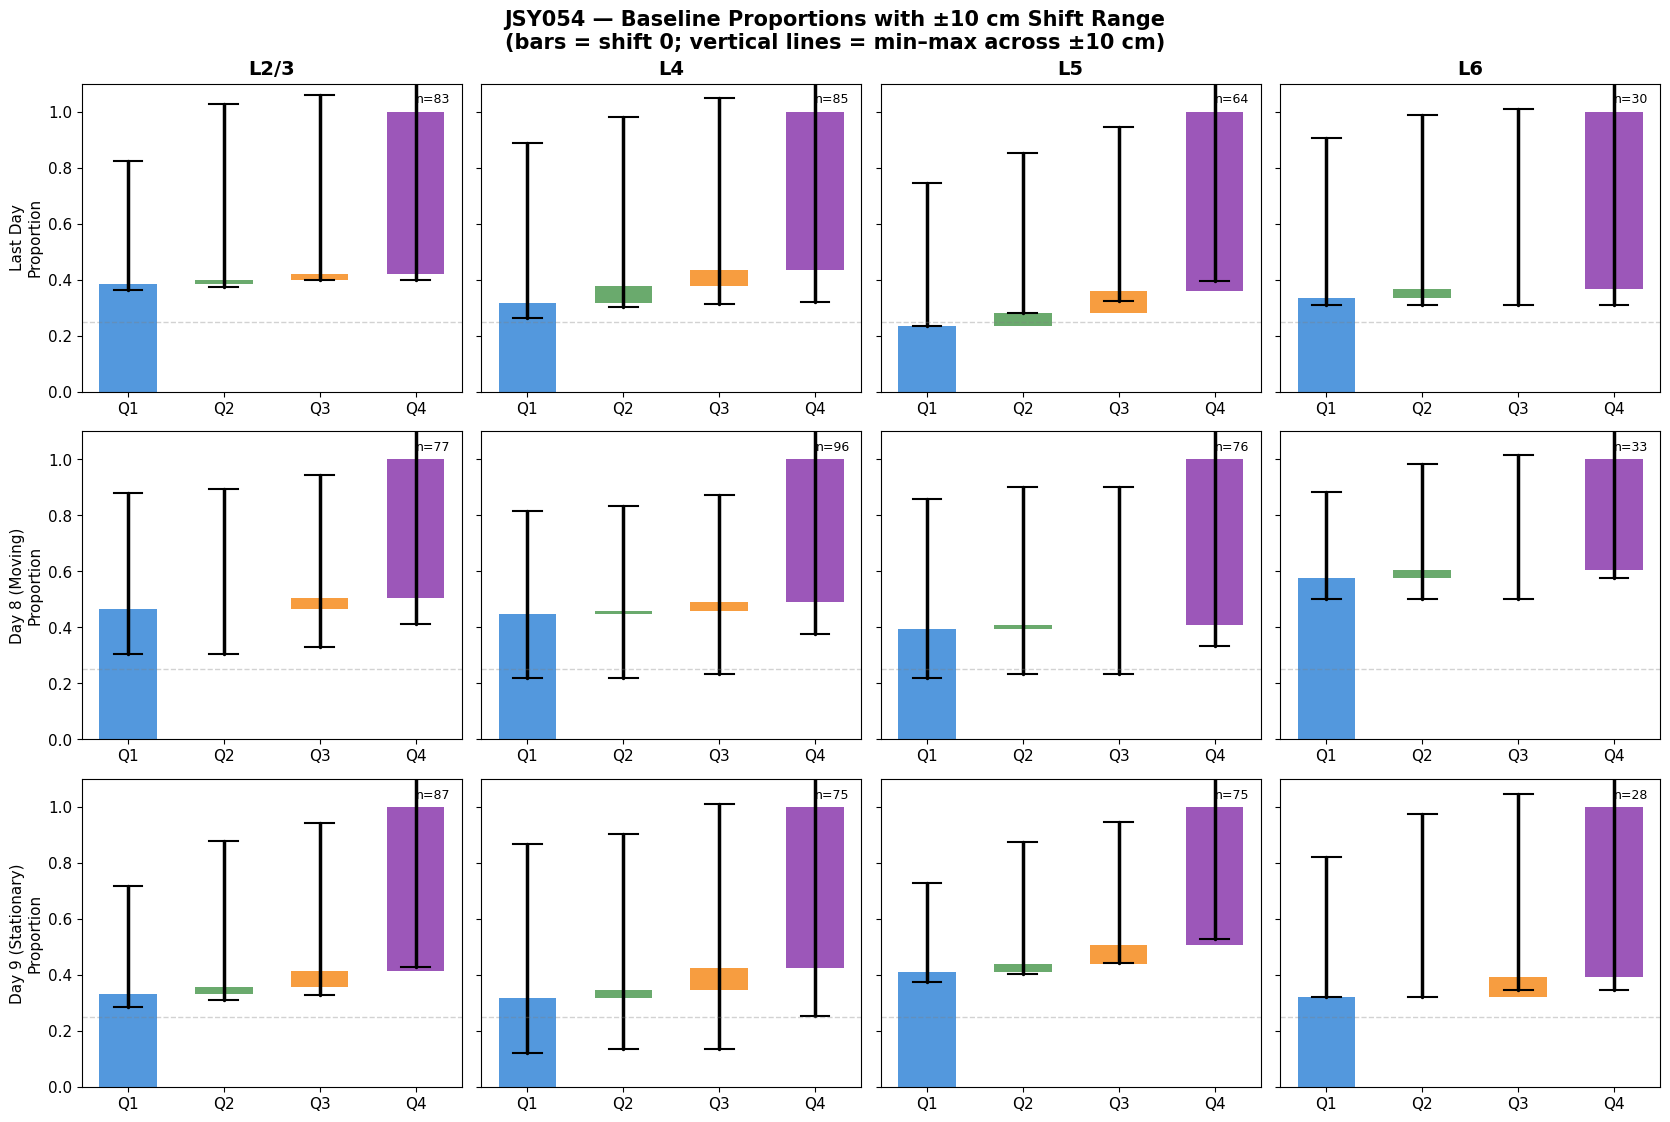

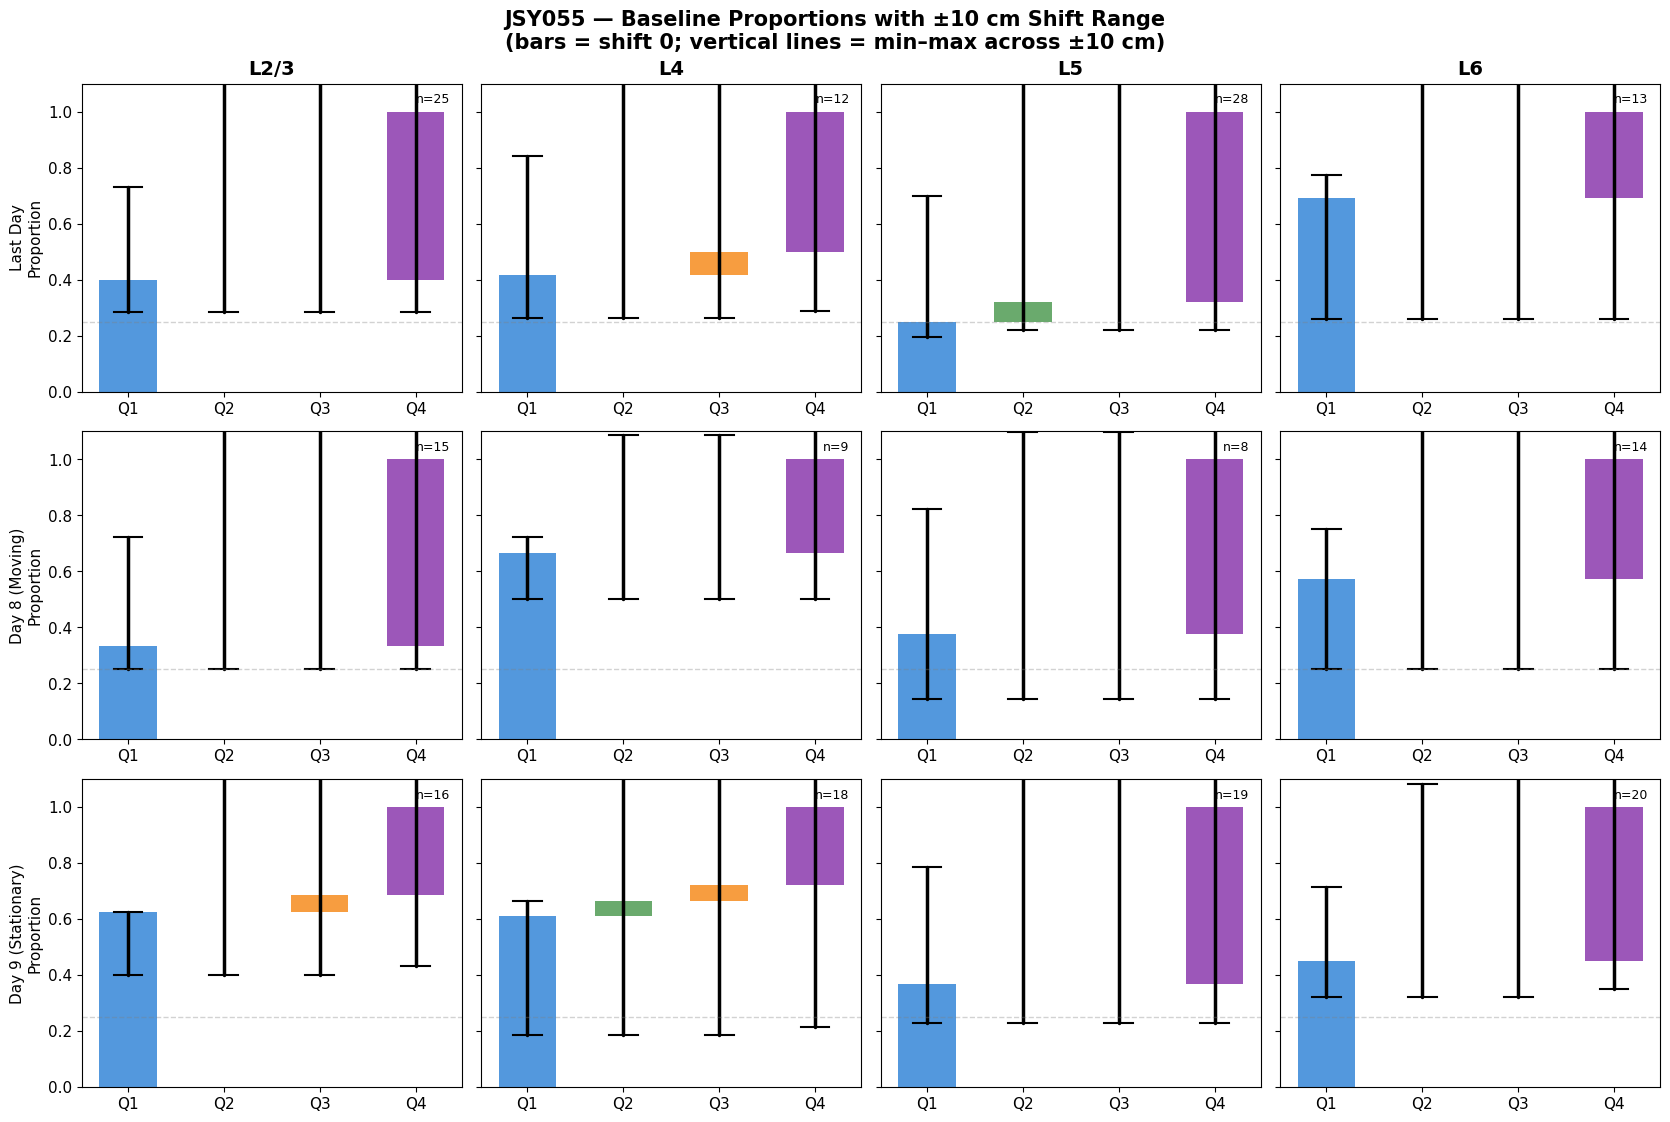

In [20]:
# ── Figure 2: Range ribbon — shows min/max across shifts ─────────────────────
# One figure per animal.
# Layout: rows = conditions, cols = layers.
# Each panel: stacked bar at baseline (shift=0), with ribbon showing
# how each proportion moves across the ±10 cm shift range.
# Narrow ribbons = robust; wide ribbons = sensitive to window placement.

LANDMARK_COLORS = ['#1976D2', '#388E3C', '#F57C00', '#7B1FA2']

for s in included_sessions:
    animal = s['animal_id']
    fig, axes = plt.subplots(
        len(CONDITIONS), len(LAYER_NAMES),
        figsize=(4.2 * len(LAYER_NAMES), 3.8 * len(CONDITIONS)),
        sharey=True,
    )

    for ci, (cond, cond_label) in enumerate(zip(CONDITIONS, COND_LABELS)):
        for li, layer in enumerate(LAYER_NAMES):
            ax = axes[ci, li]

            # Collect proportions across all shifts for this condition/layer
            all_props = []   # shape (n_shifts, n_landmarks)
            for shift in SHIFTS:
                d = sweep[animal][cond][shift].get(layer)
                if d is not None:
                    all_props.append(d['proportions'])
                else:
                    all_props.append(np.full(4, np.nan))
            all_props = np.array(all_props)  # (n_shifts, 4)

            # Baseline (shift=0)
            zero_idx  = SHIFTS.index(0)
            base_prop = all_props[zero_idx]
            prop_min  = np.nanmin(all_props, axis=0)
            prop_max  = np.nanmax(all_props, axis=0)

            x        = np.arange(4)
            bar_w    = 0.6
            bottom_b = 0.0
            bottom_mn = np.zeros(4)
            bottom_mx = np.zeros(4)

            for lm_i, lm_color in enumerate(LANDMARK_COLORS):
                # Stacked bar at baseline
                ax.bar(lm_i, base_prop[lm_i], bar_w,
                       bottom=bottom_b, color=lm_color, alpha=0.75)
                bottom_b += base_prop[lm_i] if not np.isnan(base_prop[lm_i]) else 0

            # Error lines from min to max for each landmark (stacked, cumulative)
            cum_min = np.zeros(4)
            cum_max = np.zeros(4)
            for lm_i in range(4):
                # cumulative sum below this landmark
                for prev in range(lm_i):
                    cum_min[lm_i] += prop_min[prev] if not np.isnan(prop_min[prev]) else 0
                    cum_max[lm_i] += prop_max[prev] if not np.isnan(prop_max[prev]) else 0

                ylo = cum_min[lm_i] + (prop_min[lm_i] if not np.isnan(prop_min[lm_i]) else 0)
                yhi = cum_max[lm_i] + (prop_max[lm_i] if not np.isnan(prop_max[lm_i]) else 0)
                ax.plot([lm_i, lm_i], [ylo, yhi], color='k', lw=2.5, solid_capstyle='round')
                ax.plot([lm_i - 0.15, lm_i + 0.15], [ylo, ylo], color='k', lw=1.5)
                ax.plot([lm_i - 0.15, lm_i + 0.15], [yhi, yhi], color='k', lw=1.5)

            ax.axhline(0.25, color='gray', lw=1, ls='--', alpha=0.35)
            ax.set_xticks(x)
            ax.set_xticklabels(LM_LABELS, fontsize=11)
            ax.set_ylim(0, 1.1)

            n_cells_base = (sweep[animal][cond][0].get(layer) or {}).get('n_cells', 0)
            ax.text(0.97, 0.97, f'n={n_cells_base}',
                    ha='right', va='top', transform=ax.transAxes, fontsize=9)

            if ci == 0:
                ax.set_title(layer, fontsize=14, fontweight='bold')
            if li == 0:
                ax.set_ylabel(f'{cond_label}\nProportion', fontsize=11)

    fig.suptitle(
        f'{animal} — Baseline Proportions with ±10 cm Shift Range\n'
        f'(bars = shift 0; vertical lines = min–max across ±10 cm)',
        fontsize=15, fontweight='bold'
    )
    plt.tight_layout()
    plt.show()

In [21]:
# ── Table: Max proportion change across the ±10 cm sweep ─────────────────────
# Reports max(prop) - min(prop) per condition × layer × landmark.
# Small values confirm robustness.

print(f'Max |Δproportion| across ±10 cm shift sweep')
print(f'(values < 0.05 are considered robust)\n')

for s in included_sessions:
    animal = s['animal_id']
    print(f'=== {animal} ===')

    for cond, cond_label in zip(CONDITIONS, COND_LABELS):
        print(f'  {cond_label}')
        header = f'{"":>6}  ' + '  '.join(f'{lm:>8}' for lm in LM_LABELS)
        print(f'  {header}')

        for layer in LAYER_NAMES:
            all_props = []
            for shift in SHIFTS:
                d = sweep[animal][cond][shift].get(layer)
                if d is not None:
                    all_props.append(d['proportions'])
                else:
                    all_props.append(np.full(4, np.nan))
            all_props = np.array(all_props)
            delta     = np.nanmax(all_props, axis=0) - np.nanmin(all_props, axis=0)
            flags     = ['*' if v > 0.05 else ' ' for v in delta]
            vals_str  = '  '.join(f'{v:7.3f}{f}' for v, f in zip(delta, flags))
            print(f'    {layer:>4}:  {vals_str}')
        print()

Max |Δproportion| across ±10 cm shift sweep
(values < 0.05 are considered robust)

=== JSY044 ===
  Last Day
                Q1        Q2        Q3        Q4
    L2/3:    0.333*    0.391*    0.000     0.721*
      L4:    0.355*    0.236*    0.008     0.537*
      L5:    0.512*    0.157*    0.024     0.643*
      L6:    0.282*    0.149*    0.000     0.273*

  Day 8 (Moving)
                Q1        Q2        Q3        Q4
    L2/3:    0.607*    0.214*    0.000     0.571*
      L4:    0.393*    0.267*    0.000     0.333*
      L5:    0.429*    0.091*    0.125*    0.375*
      L6:    0.433*    0.167*    0.000     0.500*

  Day 9 (Stationary)
                Q1        Q2        Q3        Q4
    L2/3:    0.210*    0.160*    0.000     0.280*
      L4:    0.100*    0.155*    0.000     0.192*
      L5:    0.355*    0.245*    0.027     0.375*
      L6:    0.227*    0.227*    0.000     0.000 

=== JSY051 ===
  Last Day
                Q1        Q2        Q3        Q4
    L2/3:    0.500*    0.500